야옹이 부스터~~~

소규모 데이터에서도 비교적 안정적으로 돌릴 수 있는 모델

로그 레벨을최소화 하는 파라미터...


변수 중요도 산출 함수에 차이 존재



# [LAB 08] 지도학습 > 예측 >앙상블 > 07.CatBoost

## #01. CatBoost 개요
- 결정트리 기반 그래디언트 부스팅 회귀/분류 모델
- 이전 모델의 오차를 보완하는 트리들을 순차적으로 결합
- Yandex에서 개발한 부스팅 라이브러리
- 범주형 변수 처리에 특화된 부스팅 모델
- XGBoost,LightGBM 대비 전처리 부담이 매우 낮음
- 보통 트리 모델들은 문자열 변수 처리가 어렵고, 원핫인코딩을 필요로 하면서 컬럼 수가 너무 많아지는 문제가 있었는데 CatBoost 는 자동 인코딩해줘서 범주형 변수를 그대로 넣어도 된다

### [1] 핵심 구조적 특징
#### (1) Ordered Boosting (순서 기반 부스팅)
- 기존 부스팅의 문제
  - 학습 데이터 전체를 사용해 잔차 계산
  - 타깃 누수 (target leakage) 발생 가능
- CatBoost 방식
  - 데이터 순서를 고려하여 잔차 계산
  - 과거 데이터만 사용해 현재 샘플의 잔차 추정
- 효과
  - 과적합 감소
  - 소규모 데이터에서도 안정적인 성능 유지


*타깃 누수란? 
- 예측 시점에는 알 수 없는 정답 정보가 학습 중에 들어간 상태, catboost 는 이 현상이 나타나는걸 방지해줌
- 부스팅의 경우 앞에서 틀린 부분을 보완하는 형식으로 학습되기 떄문에 첫 트리에서 정답 힌트를 받으면 다음 트리는 그걸 더 증폭시키다보니 Train 성능이 과도하게 좋고, CV 도 비정상적으로 높아질 수 있음
- 그렇다보니, 어떤 샘플을 예측할 떄 그 이후의 데이터를 쓰지 않도록 설계되어서 데이터 순서를 고려한다는 설명이 생긴것

예를 들어서 내일 비가 올까? 하는 질문에, 누군가가 어제 우산이 많이 팔렸으니까 내일 비가 올거야. 라고 말하면
이전 데이터들에 대해서는 예측이 좋아보이지만 실제 데이터에서는 쓸 수 게 되는 모형이 되는 것
설명은 그럴듯 하지만실제 예측은 불가능해지는

#### (2) Symmetric Tree (대칭 트리)
- 모든 리프 노드가 동일한 분기 구조를 가짐
- 특징
  - 트리 구조 단순
  - 예측 속도 빠름
  - 메모리 접근 패턴 안정적
- 단점
  - Leaf-wise 트리 대비 표현력은 제한적


### [2] 범주형 변수 처리 특징 (매우 중요)
- One-Hot Encoding 불필요
- 문자열/정수 범주형 변수 그대로 입력 가능
- 내부 처리 방식
  - Target Statistics 기반 인코딩
  - Ordered Boosting 과 결합하여 누수 방지


### [3] CatBoost 사용이 특히 적합한 경우
- 범주형 변수가 많은 데이터
- 데이터 크기가 크지 않은 경우
- 전처리를 최소화하고 싶은 경우
- 안정성과 재현성을 중시하는 분석 환경


### [4] LightGBM / XGBoost 와의 간단 비교

| 구분 | CatBoost | LightGBM | XGBoost |
|---|---|---|---|
| 트리 성장 방식 | Level-wise (대칭) | Leaf-wise | Level-wise |
| 범주형 변수 처리 | Native 지원 ⭐⭐⭐ | 제한적 | 미지원 |
| 과적합 제어 | Ordered Boosting | 하이퍼파라미터 의존 | 하이퍼파라미터 의존 |
| 전처리 부담 | 매우 낮음 | 중간 | 높음 |
| 대규모 데이터 | 보통 | 매우 강함 | 강함 |


- Level wise : 대칭 트리, 모든 노드를 같은 깊이로 동시에 분할하여 균형적이고 학습이 안정적이고 과적합 위험 감소 (복잡한 패턴 표현은 약함)
- Leaf wise : 손실을 가장 많이 줄이는 리프만 선택적으로 분할하여, 한쪽만 깊어질 수도 있음 , 과적합 위험 높음

## #02. 준비작업
### [1] 패키지 참조


In [23]:
from hossam import *

import pandas as pd
from pandas import merge
from pandas import Series, DataFrame

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor


#LightGBM 회귀 모델
from lightgbm import LGBMRegressor

#BoostRegressor
from xgboost import XGBRegressor

#CatBoost
from catboost import CatBoostRegressor

### [2] 성능 평가 함수 정의
- hs_get_scores()
- hs_learning_cv()
- hs_get_score_cv()
- hs_feature_importance()
- hs_shap_analysis()
- hs_shap_dependence_analysis()-

#### 성능 평가 함수

In [12]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 변수 중요도 확인

In [13]:
from sklearn.inspection import permutation_importance

def hs_feature_importance(model, x, y):
    perm = permutation_importance(
        estimator=model,
        X=x,
        y=y,
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    # 결과 정리
    perm_df = DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=x.columns,
    ).sort_values("importance_mean", ascending=False)

    # 시각화
    df = perm_df.sort_values(by="importance_mean", ascending=False)

    figsize = (1280 / my_dpi, 600 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance_mean", y=df.index)

    ax.set_title("Permutation Importance")
    ax.set_xlabel("Permutation Importance (mean)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return perm_df


#### 과적합 판정 함수

In [14]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [15]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [16]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


#### SHAP 분석

In [17]:
def hs_shap_analysis(
    model,
    x: DataFrame,
    plot: bool = True,
    width: int = 1600,
    height: int = 800,
):
    # -------------------------------------------------
    # 1. SHAP Explainer 생성 (트리 모델용)
    # -------------------------------------------------
    explainer = shap.TreeExplainer(model)

    # -------------------------------------------------
    # 2. SHAP 값 계산
    # shape = (n_samples, n_features)
    # -------------------------------------------------
    shap_values = explainer.shap_values(x)

    # -------------------------------------------------
    # 3. SHAP DataFrame 변환
    # -------------------------------------------------
    shap_df = DataFrame(
        shap_values,
        columns=x.columns,
        index=x.index,
    )

    # -------------------------------------------------
    # 4. SHAP 요약 통계
    # -------------------------------------------------
    summary_df = DataFrame(
        {
            "feature": shap_df.columns,
            "mean_abs_shap": shap_df.abs().mean().values,
            "mean_shap": shap_df.mean().values,
            "std_shap": shap_df.std().values,
        }
    )

    # -------------------------------------------------
    # 5. 영향 방향 (보수적 기준)
    # -------------------------------------------------
    summary_df["direction"] = np.where(
        summary_df["mean_shap"] > 0,
        "양(+) 경향",
        np.where(summary_df["mean_shap"] < 0, "음(-) 경향", "혼합/미약"),
    )

    # -------------------------------------------------
    # 6. 변동성 지표 (안정성 판단)
    # -------------------------------------------------
    summary_df["cv"] = (
        summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)
    )

    summary_df["variability"] = np.where(
        summary_df["cv"] < 1,
        "stable",      # 평균 대비 변동성 낮음
        "variable",    # 상황 의존적 영향
    )

    # -------------------------------------------------
    # 7. 중요도 기준 정렬
    # -------------------------------------------------
    summary_df = (
        summary_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # 8. 중요 변수 판별 (누적 80%)
    # -------------------------------------------------
    total_importance = summary_df["mean_abs_shap"].sum()

    summary_df["importance_ratio"] = (
        summary_df["mean_abs_shap"] / total_importance
    )

    summary_df["importance_cumsum"] = (
        summary_df["importance_ratio"].cumsum()
    )

    summary_df["is_important"] = np.where(
        summary_df["importance_cumsum"] <= 0.80,
        "core",        # 핵심 변수
        "secondary",   # 보조 변수
    )

    # -------------------------------------------------
    # 9. SHAP Summary Plot
    # -------------------------------------------------
    if plot:
        shap.summary_plot(shap_values, x, show=False)

        fig = plt.gcf()
        fig.set_size_inches(width / 100, height / 100)

        plt.title("SHAP Summary Plot", fontsize=10, pad=10)
        plt.xlabel("SHAP value", fontsize=8)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    # -------------------------------------------------
    return summary_df, shap_values


#### SHAP dependance

In [18]:
def hs_shap_dependence_analysis(
    summary_df: DataFrame,
    shap_values,
    x_train: DataFrame,
    include_secondary: bool = False, #core 변수가 너무 적을 때, True 로 설정하면 secondary 까지 포함
    width: int = 1600,
    height: int = 800,
):
    # 1. 주 대상 변수 (Core + Variable)
    main_features = summary_df[
        (summary_df["is_important"] == "core")
        & (summary_df["variability"] == "variable")
    ]["feature"].tolist()

    # 2. 상호작용 후보 변수
    interaction_features = summary_df[
        summary_df["is_important"] == "core"
    ]["feature"].tolist()

    if include_secondary and len(interaction_features) < 2:
        interaction_features.extend(
            summary_df[summary_df["is_important"] == "secondary"]["feature"].tolist()
        )

    # 3. 변수 쌍 생성 (자기 자신 제외)
    pairs = []
    for f in main_features:
        for inter in interaction_features:
            # 자기 자신과의 조합은 제외
            if f != inter:
                pairs.append((f, inter))

    # 중요도 순 정렬 (주 변수 기준)
    importance_rank = {}
    for i, row in summary_df.iterrows():
        importance_rank[row["feature"]] = i

    pairs = sorted(
        pairs,
        key=lambda x: importance_rank.get(x[0], 999),
    )

    # 4. dependence plot 일괄 생성
    for feature_name, interaction_name in pairs:
        shap.dependence_plot(
            feature_name,
            shap_values,
            x_train,
            interaction_index=interaction_name,
            show=False,
        )

        # SHAP figure 직접 제어
        fig = plt.gcf()
        fig.set_size_inches(width / my_dpi, height / my_dpi)

        plt.title(
            f"SHAP Dependence Plot: {feature_name} × {interaction_name}",
            fontsize=10,
            pad=10,
        )

        plt.xlabel(feature_name, fontsize=10)
        plt.ylabel(f"SHAP value for {feature_name}", fontsize=10)

        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    return pairs


### [3] 데이터 가져오기 + 인덱스 ,명목형 변환

In [19]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)


# XGBoost 라서 astype int 처리
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련, 학습 데이터 분리

In [20]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #03. CatBoost 모델 적합
### [1] 주요 하이퍼 파라미터

| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|---|---|---|---|---|
| iterations | ⭐⭐⭐ | 부스팅 트리 개수 (n_estimators와 동일 개념) | 1000 | [300, 500, 800, 1000] |
| learning_rate | ⭐⭐⭐ | 각 트리의 학습률 (트리 기여도) | 0.03 | [0.01, 0.03, 0.1] |
| depth | ⭐⭐⭐ | 트리 깊이 (대칭 트리 구조의 핵심 복잡도 제어) | 6 | [4, 6, 8, 10] |
| l2_leaf_reg | ⭐⭐⭐ | 리프 노드 L2 정규화 계수 (과적합 제어 핵심) | 3.0 | [1, 3, 5, 10] |
| min_data_in_leaf | ⭐⭐ | 리프 노드 최소 샘플 수 | 1 | [1, 10, 30, 50] |
| subsample | ⭐⭐ | 행(row) 샘플링 비율 (Stochastic Gradient Boosting) | 1.0 | [0.6, 0.8, 1.0] |
| rsm | ⭐⭐ | 열(feature) 샘플링 비율 (feature bagging) | 1.0 | [0.6, 0.8, 1.0] |
| loss_function | ⭐⭐ | 손실 함수 | 'RMSE' | 고정 |
| eval_metric | ⭐ | 평가 지표 | 'RMSE' | 고정 |
| bootstrap_type | ⭐⭐ | 샘플링 방식 (Bayesian, Bernoulli, MVS) | 'Bayesian' | ['Bayesian', 'Bernoulli'] |
| bagging_temperature | ⭐⭐ | Bayesian 부스팅 강도 (클수록 랜덤성 증가) | 1.0 | [0, 1, 5] |
| random_strength | ⭐⭐ | 분기 점수에 주입되는 랜덤 노이즈 강도 | 1.0 | [0, 1, 5] |
| early_stopping_rounds | ⭐⭐ | 조기 종료 기준 | None | [50, 100] |
| cat_features | ⭐⭐⭐ | 범주형 변수 인덱스 또는 컬럼명 지정 | None | 고정 (데이터 의존) |
| random_state | ✅ | 재현성 시드 | None | 52 |
| thread_count | ✅ | 병렬 처리 스레드 수 | -1 | -1 |


In [21]:
base_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    cat_features=['weekend', 'holiday'],
    random_state=52,
    logging_level="Silent"
)

param_grid = {
    "iterations": [300, 500],
    "learning_rate": [0.01, 0.03, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5],
    "subsample": [0.8, 1.0],
}

gs = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gs.fit(
    x_train,
    y_train
)

best_model = gs.best_estimator_
best_model


### [2] 성능 평가


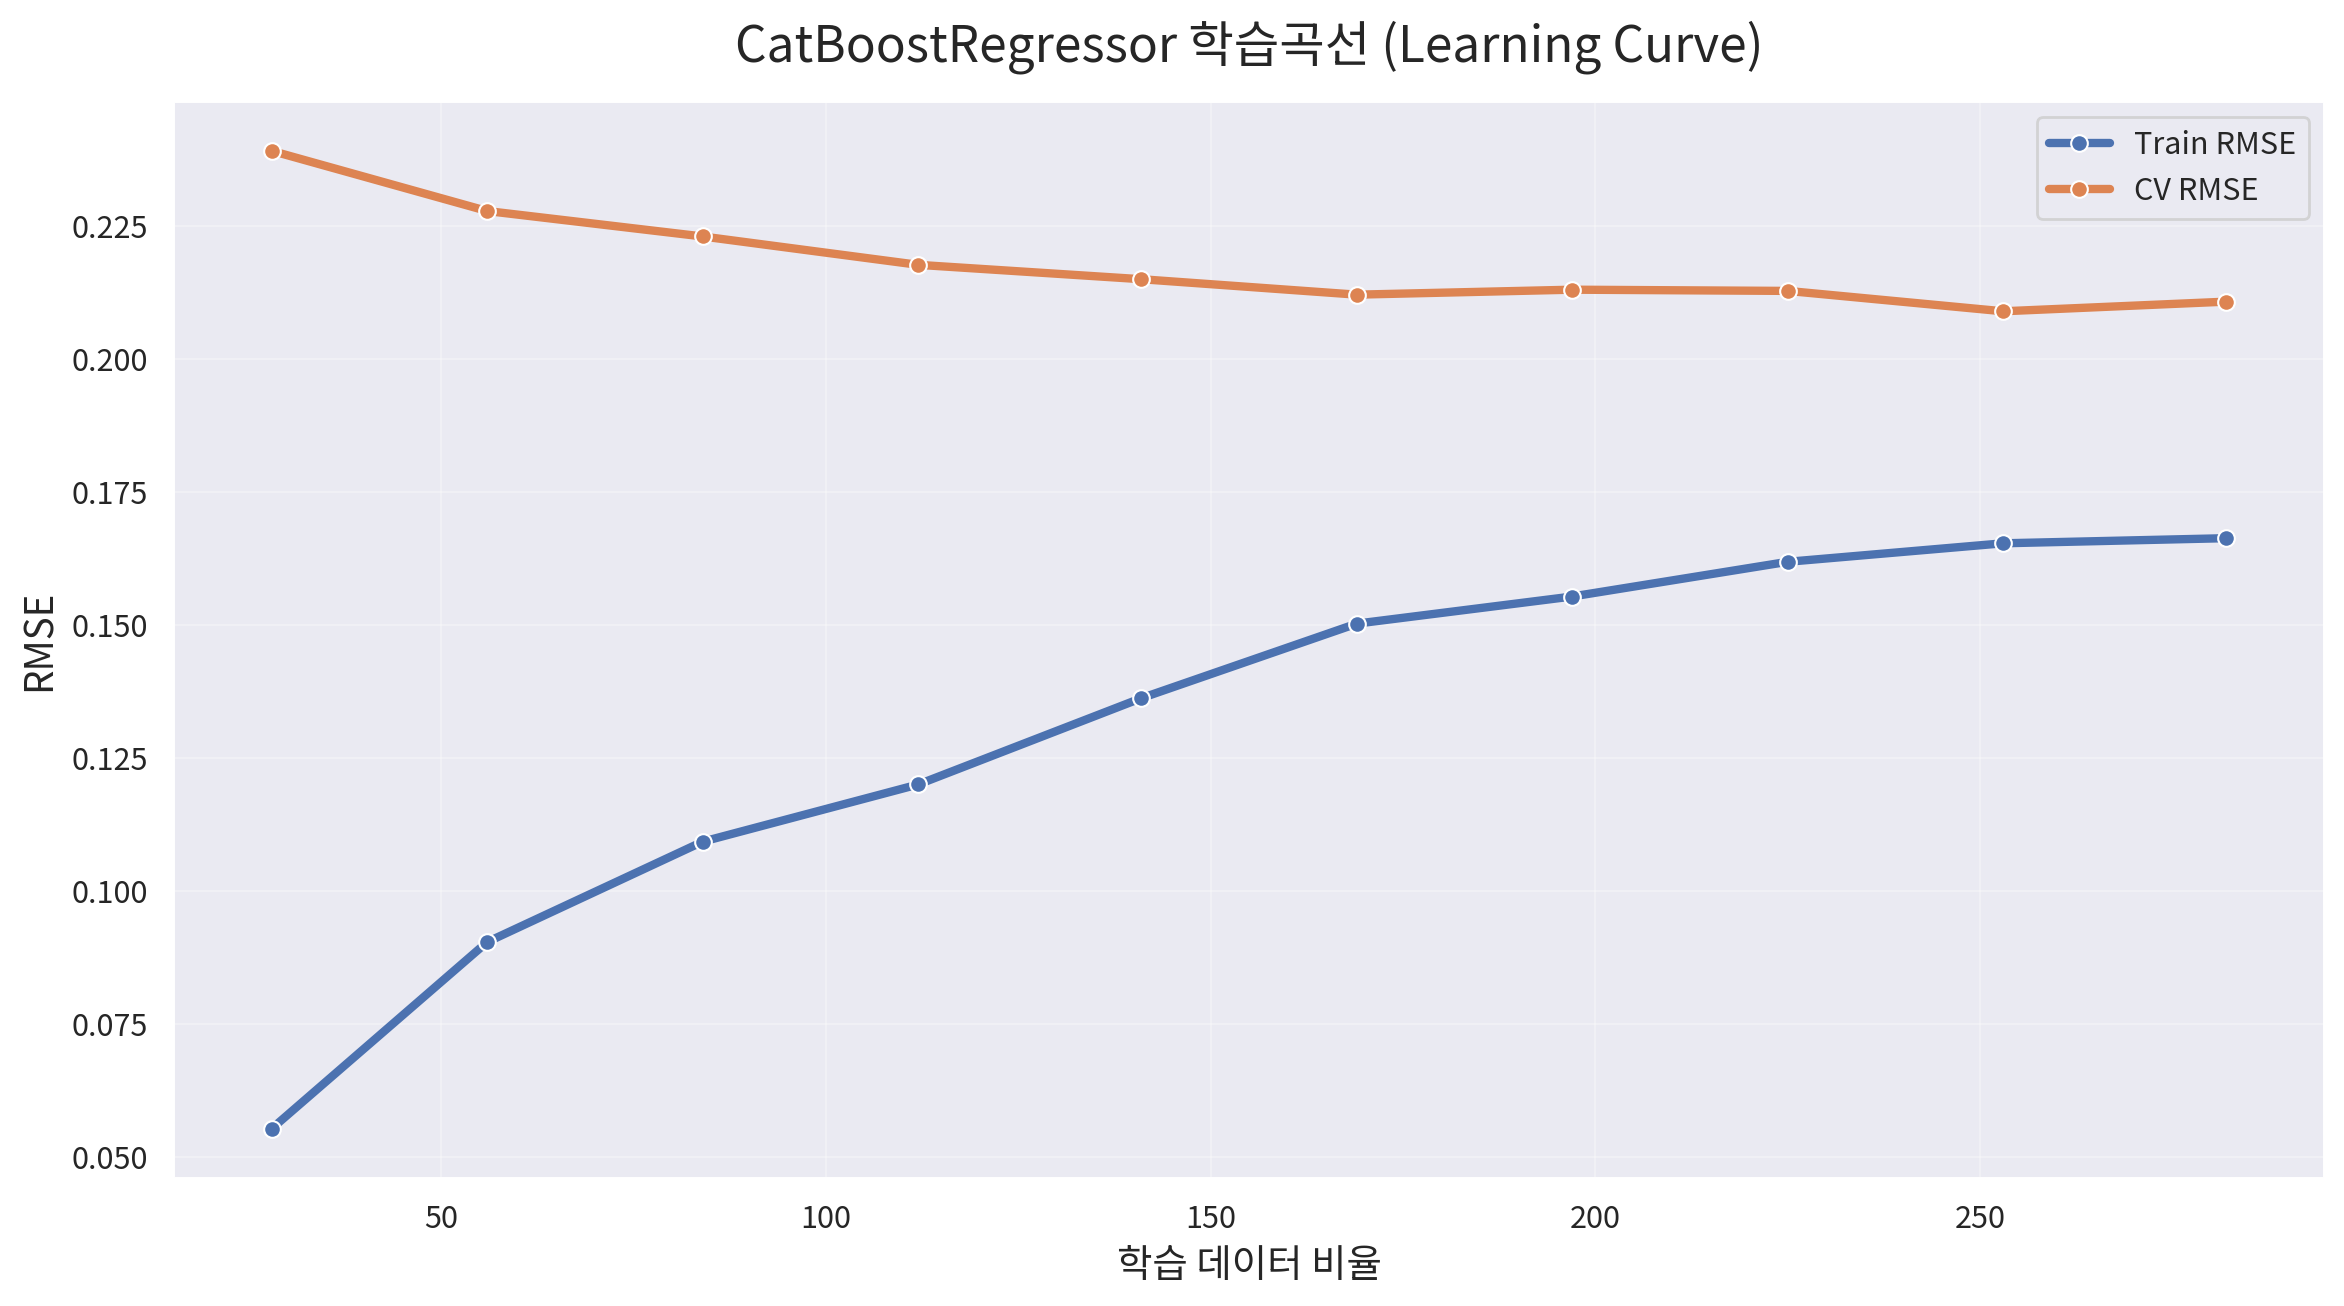

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
CatBoostRegressor,0.815,0.131,0.027,0.164,0.008,-0.011,0.166,0.211,0.013,0.789,0.063,⚠️ 과대적합


In [24]:
hs_get_score_cv(best_model,x_train,y_train,x,y)

## #04. Feature Importance
### [1] 변수 중요도 추출

In [25]:
imp = best_model.get_feature_importance(type="FeatureImportance")

imp_df = DataFrame(
    {"importance": imp},
    index=best_model.feature_names_
)

# 비율 + 누적합
imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()

imp_df = imp_df.sort_values("importance", ascending=False)
imp_df["cumsum"] = imp_df["ratio"].cumsum()

imp_df


,importance,ratio,cumsum
weekend,31.444,0.314,0.314
holiday,29.792,0.298,0.612
marketing_cost,14.875,0.149,0.761
rain_mm,8.319,0.083,0.844
avg_price,8.058,0.081,0.925
visitors,3.741,0.037,0.962
temperature,2.283,0.023,0.985
delivery_ratio,1.488,0.015,1.000


### [2] 시각화

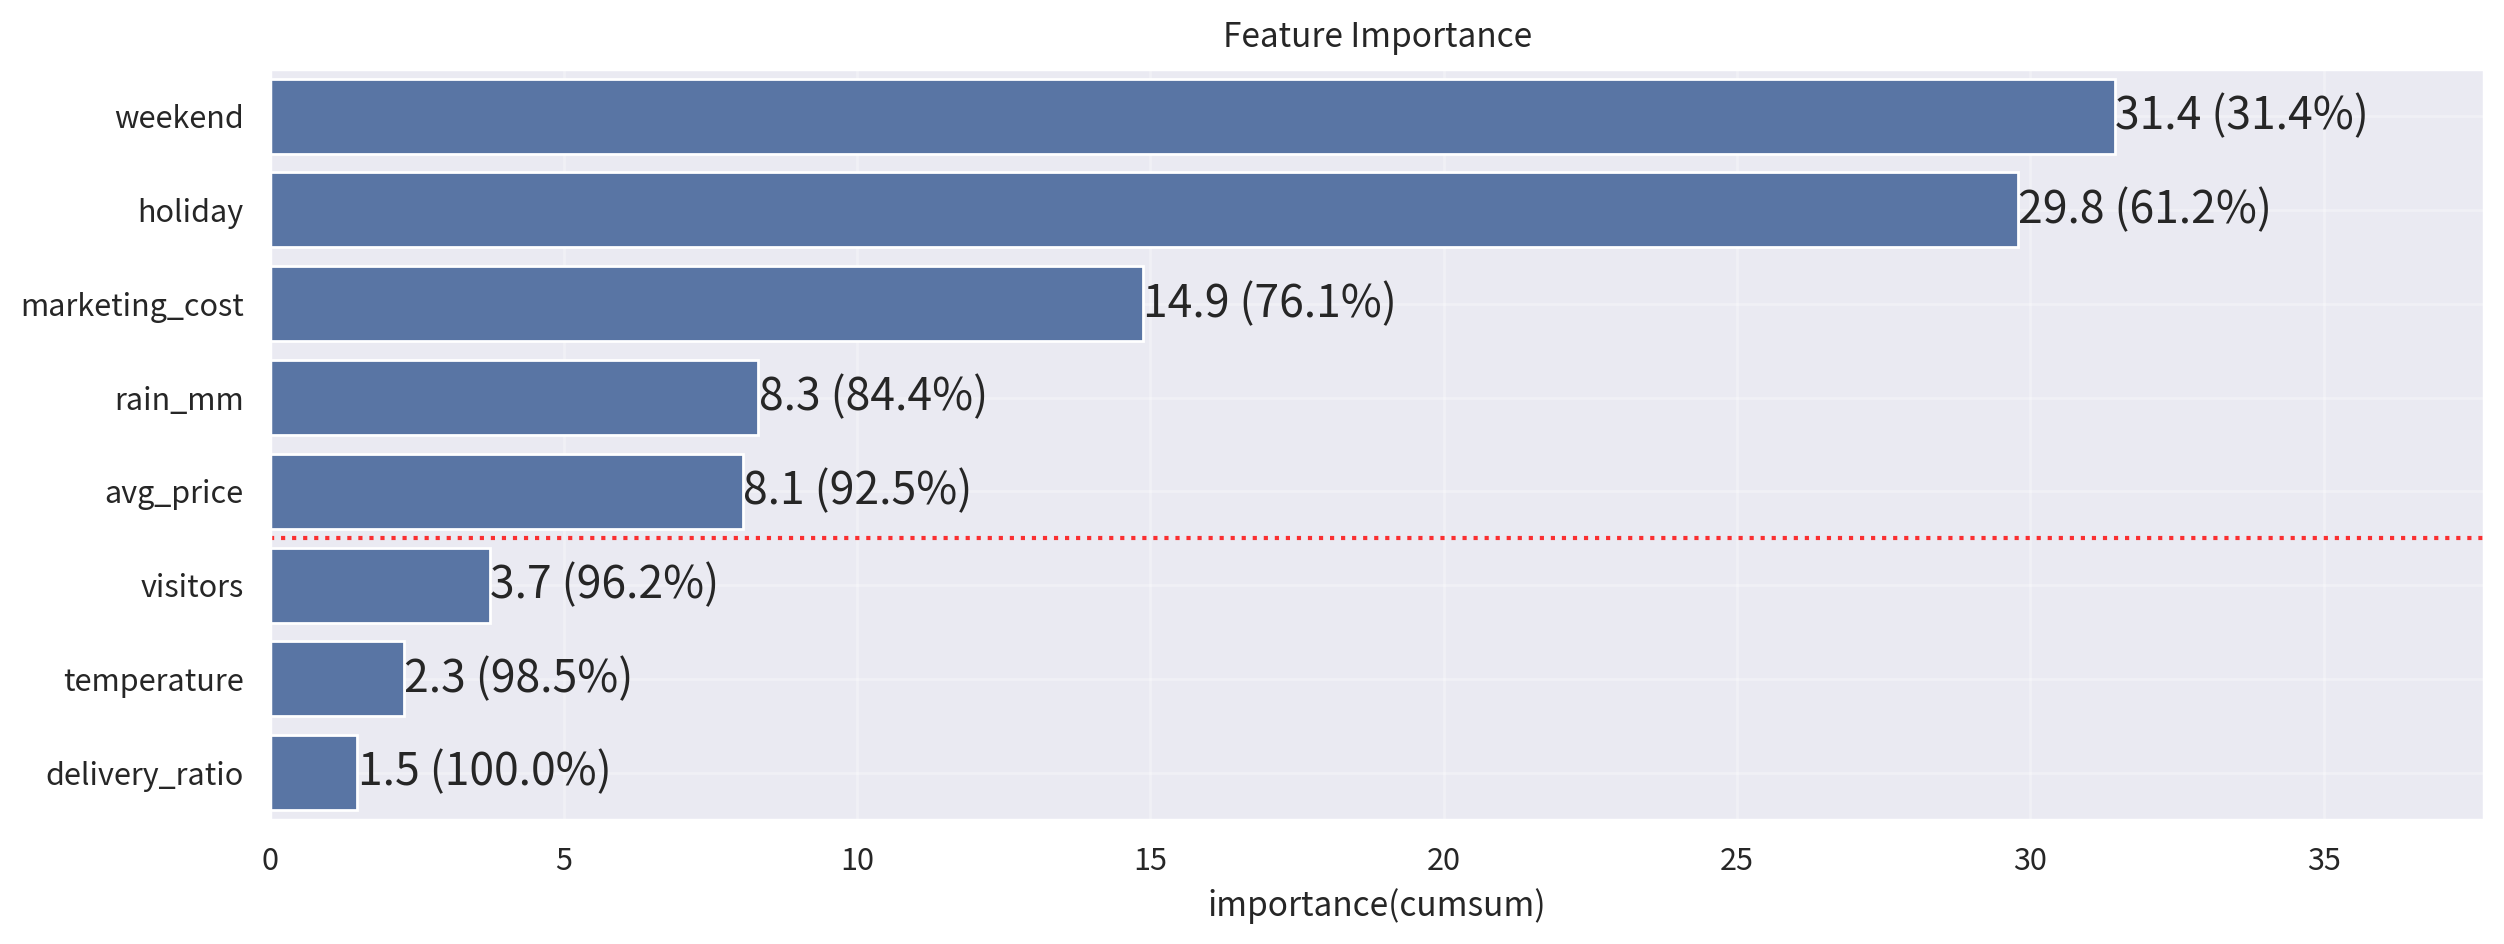

In [26]:
df = imp_df.sort_values(by="ratio", ascending=False)
threshold = 0.9

figsize = (1280 / 100, 500 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.barplot(data=df, x="importance", y=df.index)

# 값 라벨 추가
for i, v in enumerate(imp_df["importance"]):
    ax.text(
        v + 0.005,                                   # 막대 끝에서 약간 오른쪽
        i,                                           # y 위치
        f"{v:.1f} ({imp_df.iloc[i]['cumsum']*100:.1f}%)",  # 표시 형식
        va="center"
    )

ax.set_title("Feature Importance", fontsize=12, pad=8)
ax.set_xlabel("importance(cumsum)", fontsize=12)
ax.set_ylabel(None)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, imp_df["importance"].max() * 1.2)

# 90% 처음 도달하는 인덱스 (0-based)
cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)

# x축은 rank 기준으로 +1
cut_rank = (int(cut_idx) + 1) - 0.5

# 90% 도달 지점 수직선 (핵심)
plt.axhline(
    y=cut_rank,
    linestyle=":",
    color="red",
    alpha=0.8,
)

plt.tight_layout()
plt.show()
plt.close()


### [3] 변수 중요도 산출 함수 개선

In [28]:
def hs_feature_importance(model, x_train, y_train):
    if isinstance(model, XGBRegressor):
        booster = model.get_booster()
        imp = booster.get_score(importance_type="gain")
        imp_sr = Series(imp)
        imp_df = DataFrame(imp_sr, columns=["importance"])

    elif isinstance(model, LGBMRegressor):
        booster = model.booster_
        imp = booster.feature_importance(importance_type="gain")
        imp_df = DataFrame({"importance": imp}, index=model.feature_name_)

    elif isinstance(model, CatBoostRegressor):
        imp = model.get_feature_importance(type="FeatureImportance")
        imp_df = DataFrame({"importance": imp}, index=model.feature_names_)

    else:
        imp_df = permutation_importance(
            estimator=best_model,
            X=x_train,
            y=y_train,
            scoring="r2",
            n_repeats=30,
            random_state=42,
            n_jobs=-1,
        )

         # 결과 정리
        imp_df = DataFrame({"importance": imp_df.importances_mean},
                           index=X_train.columns)

    # 중요도 비율 + 누적중요도 계산
    imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()
    imp_df.sort_values("ratio", ascending=False, inplace=True)
    imp_df["cumsum"] = imp_df["ratio"].cumsum()

    # 시각화
    df = imp_df.sort_values(by="ratio", ascending=False)
    threshold = 0.9

    height = len(imp_df) * 60
    figsize = (1280 / 100, height / 100)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance", y=df.index)

    # 값라벨 추가
    for i, v in enumerate(imp_df["importance"]):
        ax.text(
            v + 0.005,
            i,
            f"{v:.1f} ({imp_df.iloc[i]['cumsum']*100:.1f}%)",
            va="center"
        )

    ax.set_title("Feature Importance", fontsize=9)
    ax.set_xlabel("importance(cumsum)", fontsize=9)
    ax.set_ylabel(None)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, imp_df["importance"].max() * 1.2)

    # 90% 처음 도달하는 인덱스 (0-based)
    cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)

    # x축은 rank 기준으로 +1
    cut_rank = (int(cut_idx) + 1) - 0.5

    # 90% 도달지점 수직선 (핵심)
    plt.axhline(
        y=cut_rank,
        linestyle="--",
        color="red",
        alpha=0.8,
    )

    plt.tight_layout()
    plt.show()
    plt.close()

    return imp_df

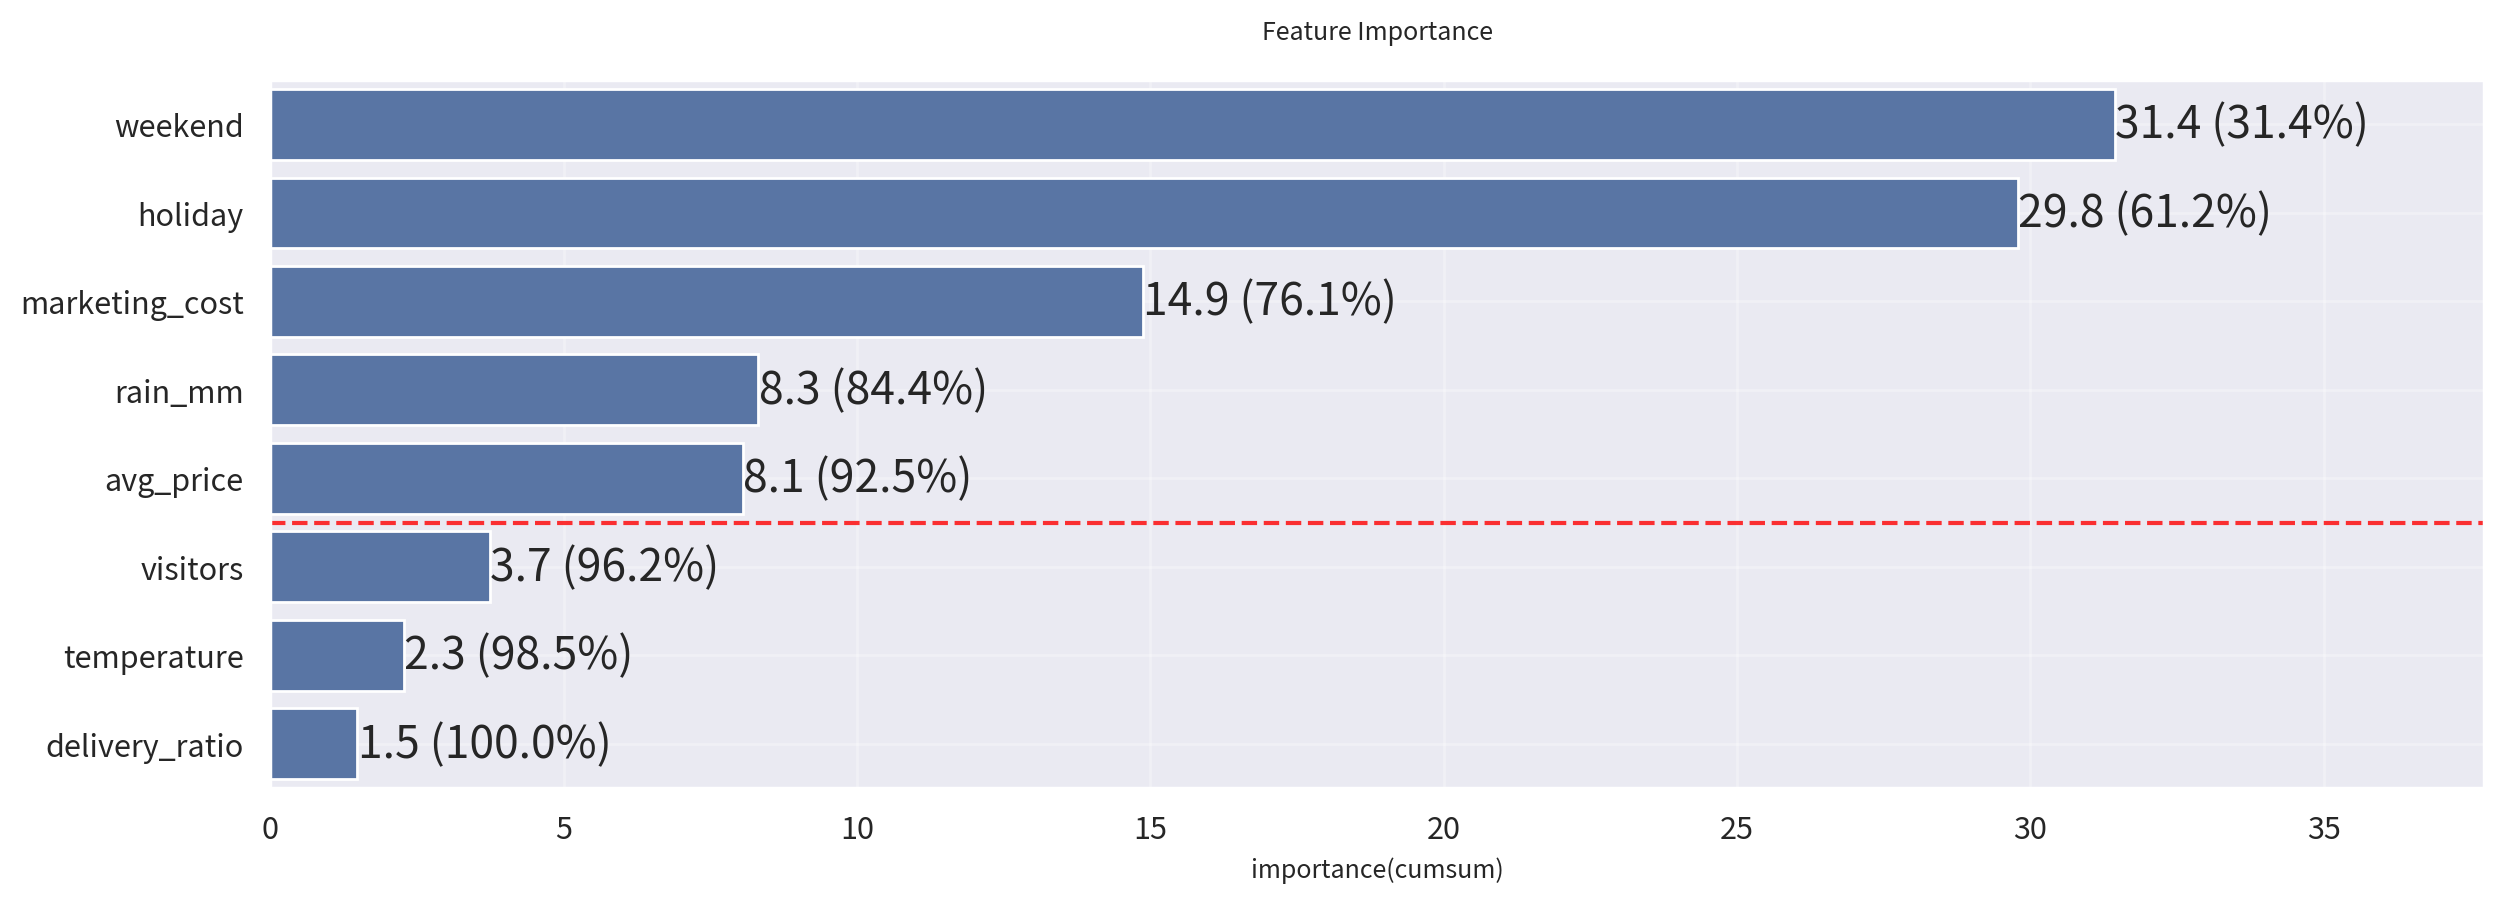

,importance,ratio,cumsum
weekend,31.444,0.314,0.314
holiday,29.792,0.298,0.612
marketing_cost,14.875,0.149,0.761
rain_mm,8.319,0.083,0.844
avg_price,8.058,0.081,0.925
visitors,3.741,0.037,0.962
temperature,2.283,0.023,0.985
delivery_ratio,1.488,0.015,1.000


In [29]:
hs_feature_importance(best_model,x_train,y_train)

## #05.SHAP 분석

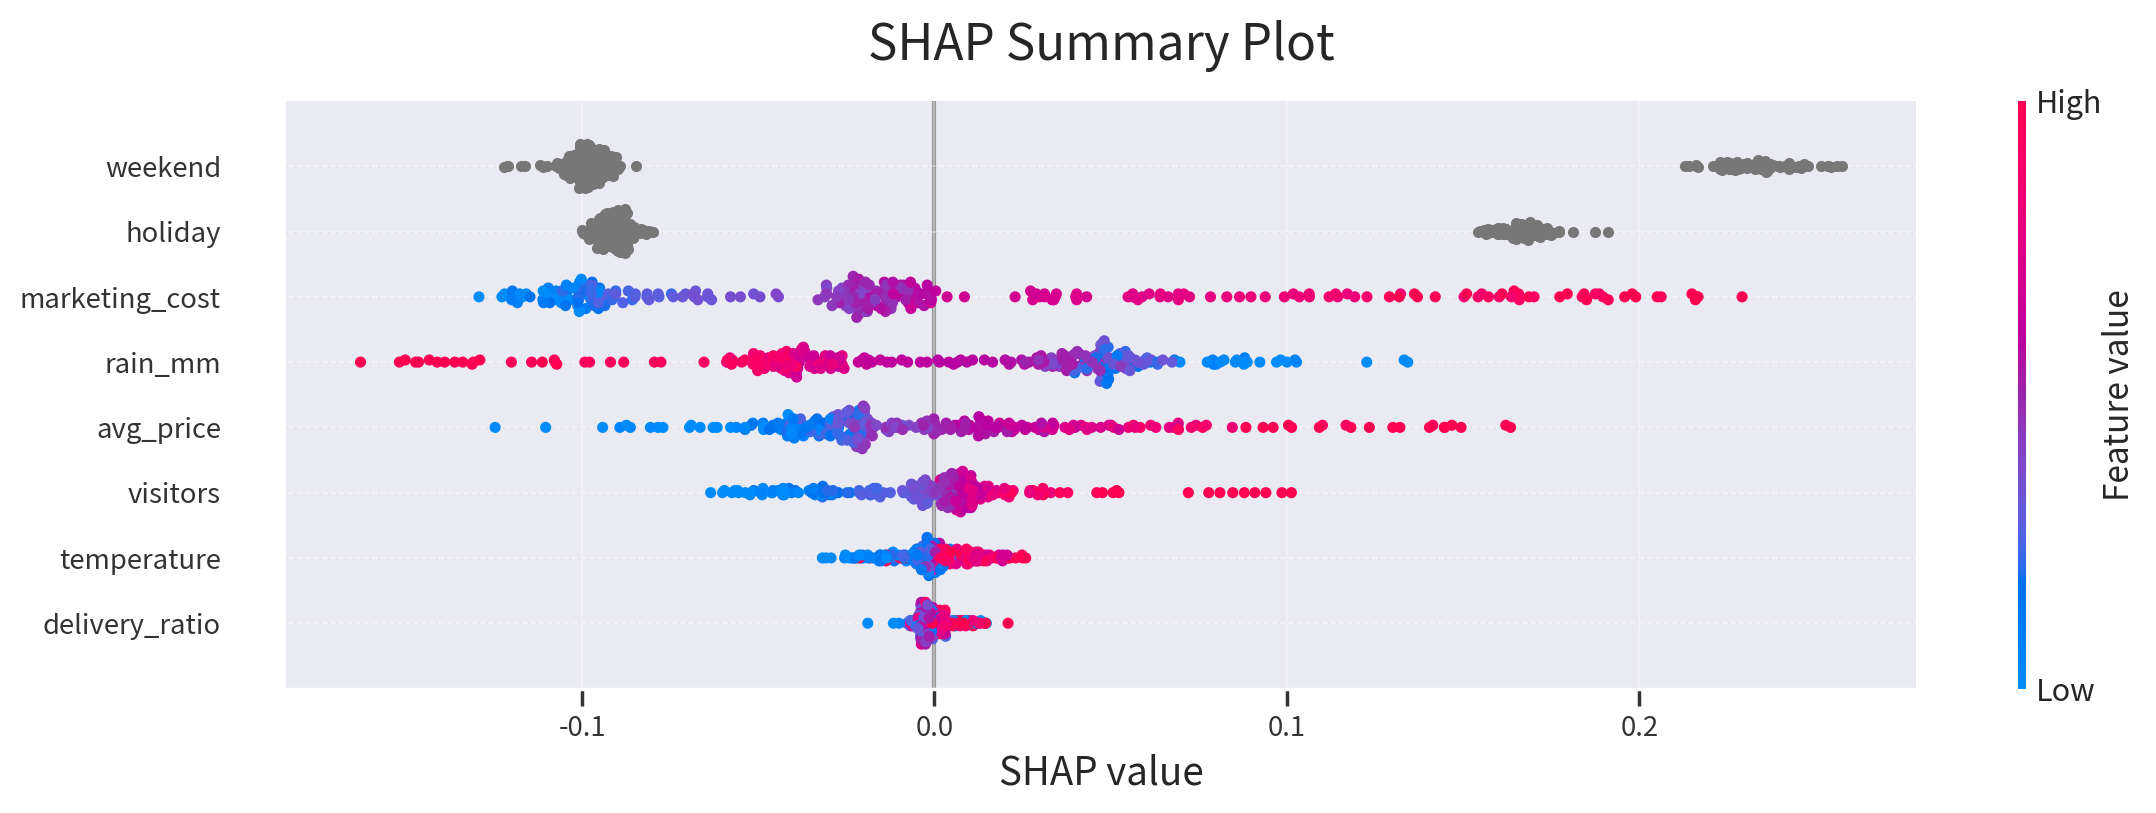

In [32]:
summary_df , shap_values = hs_shap_analysis(best_model,x_train)

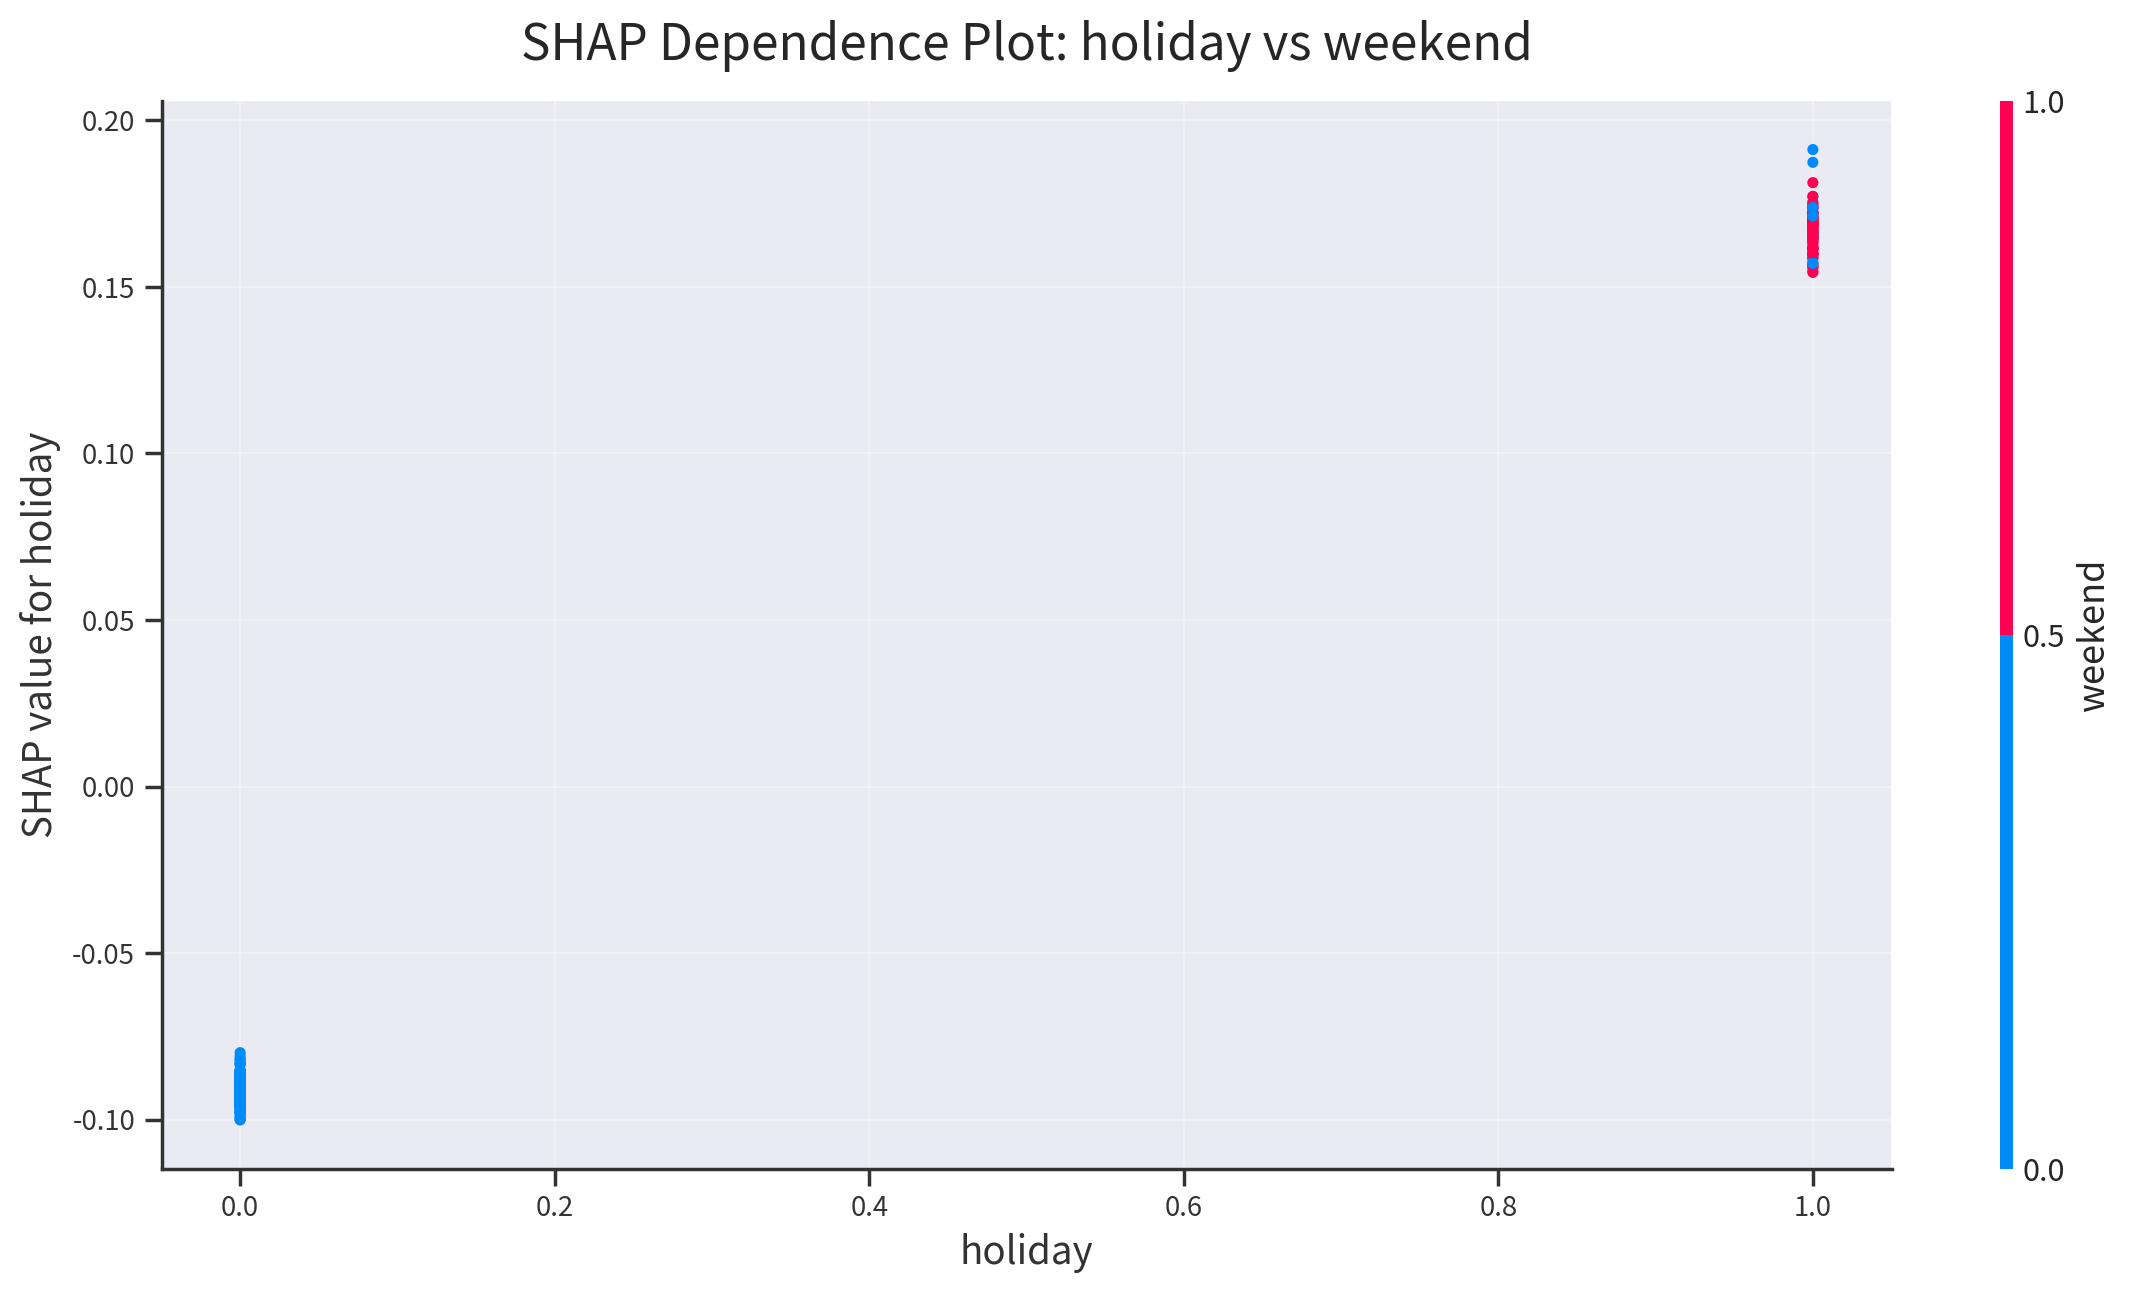

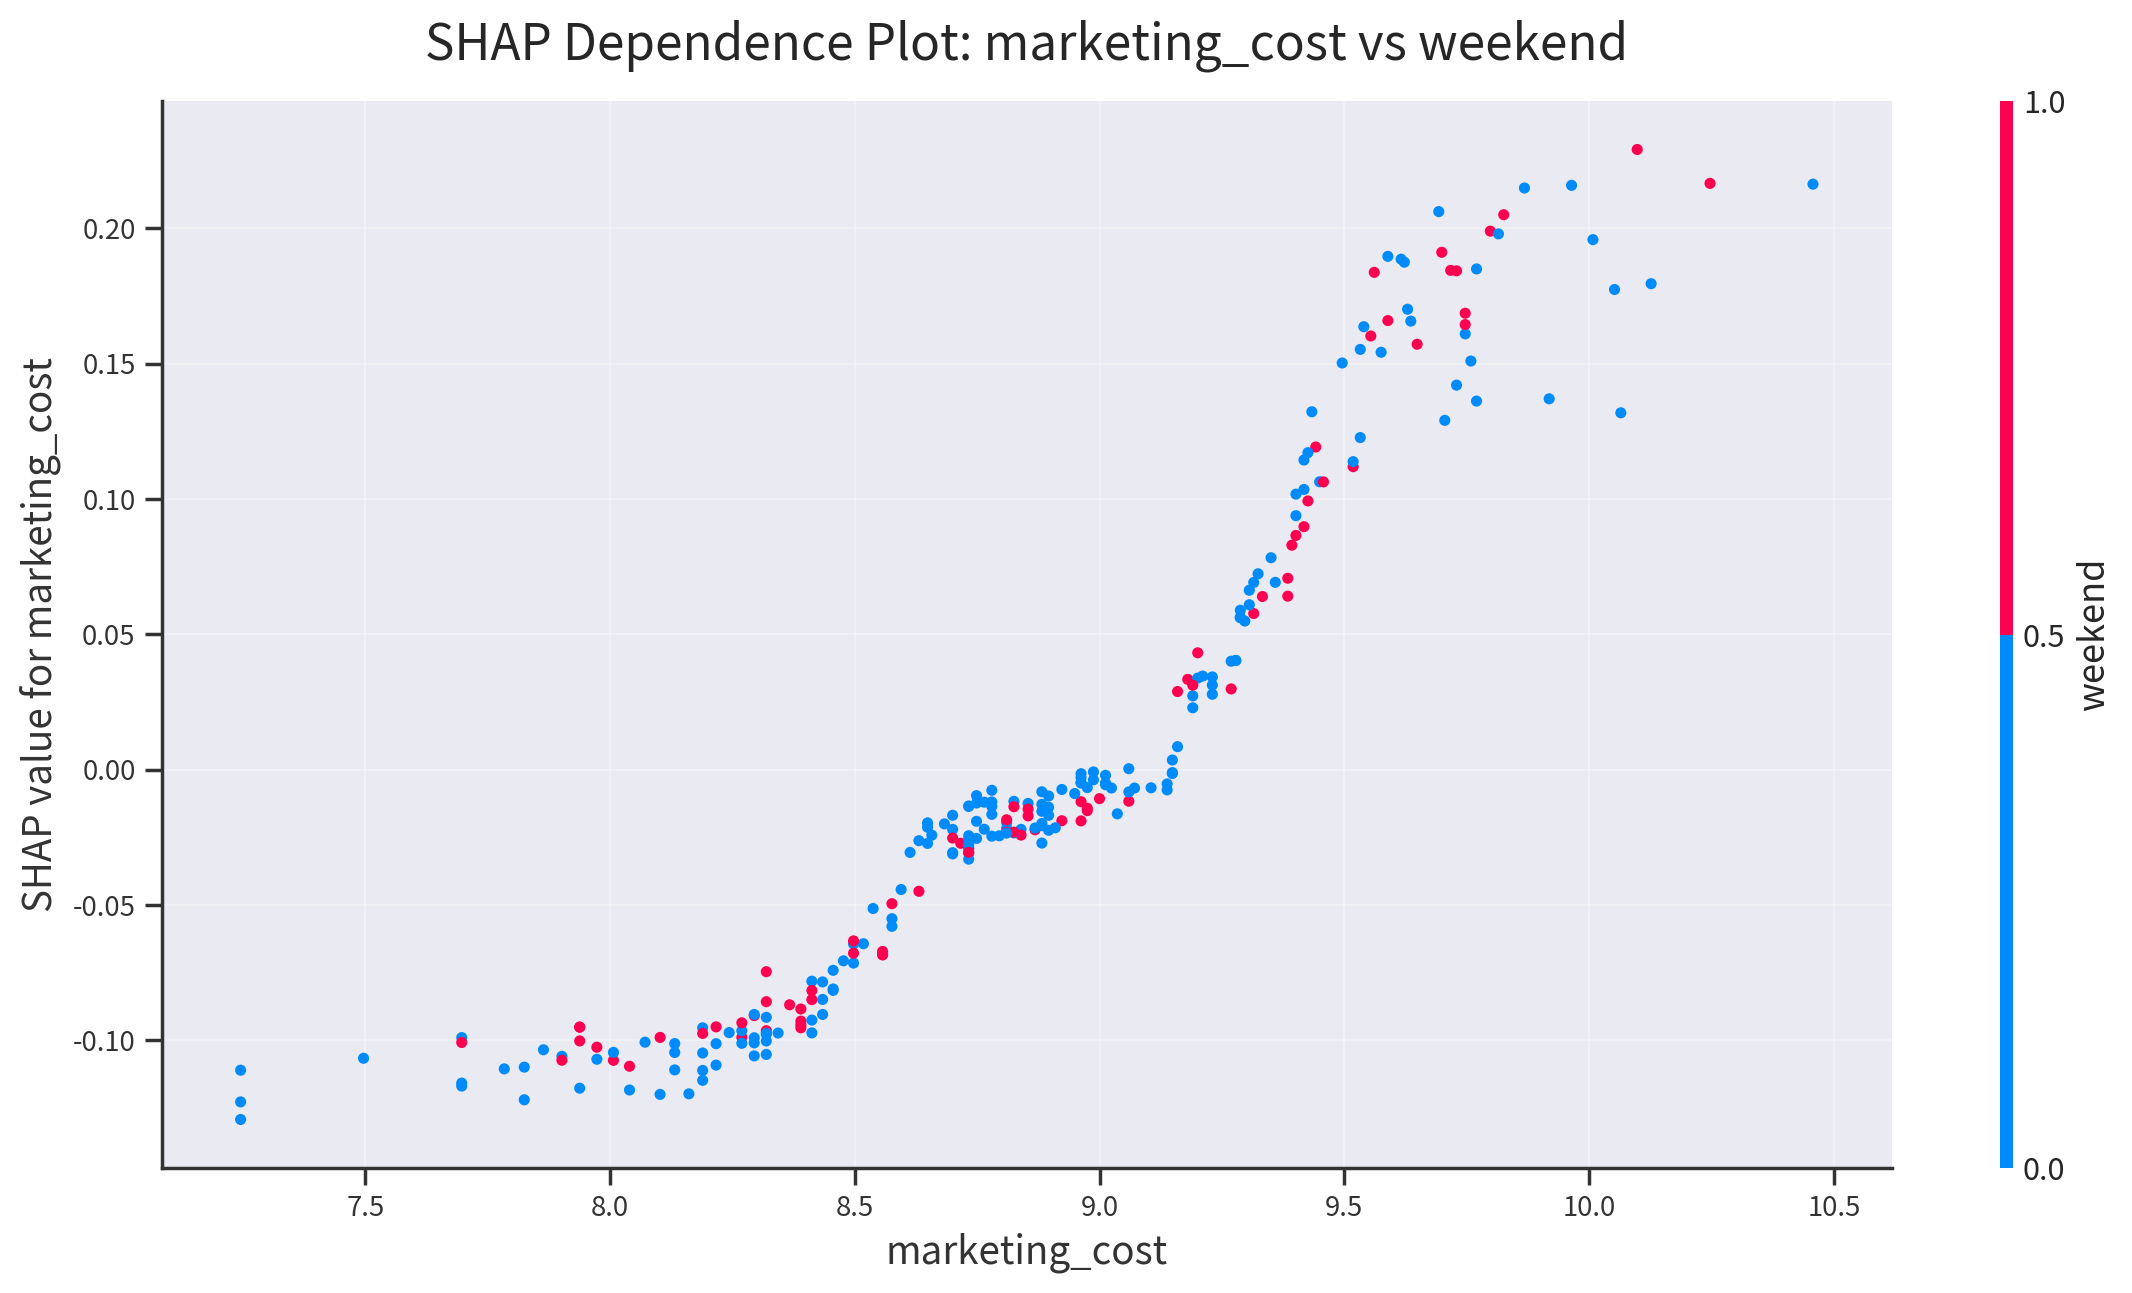

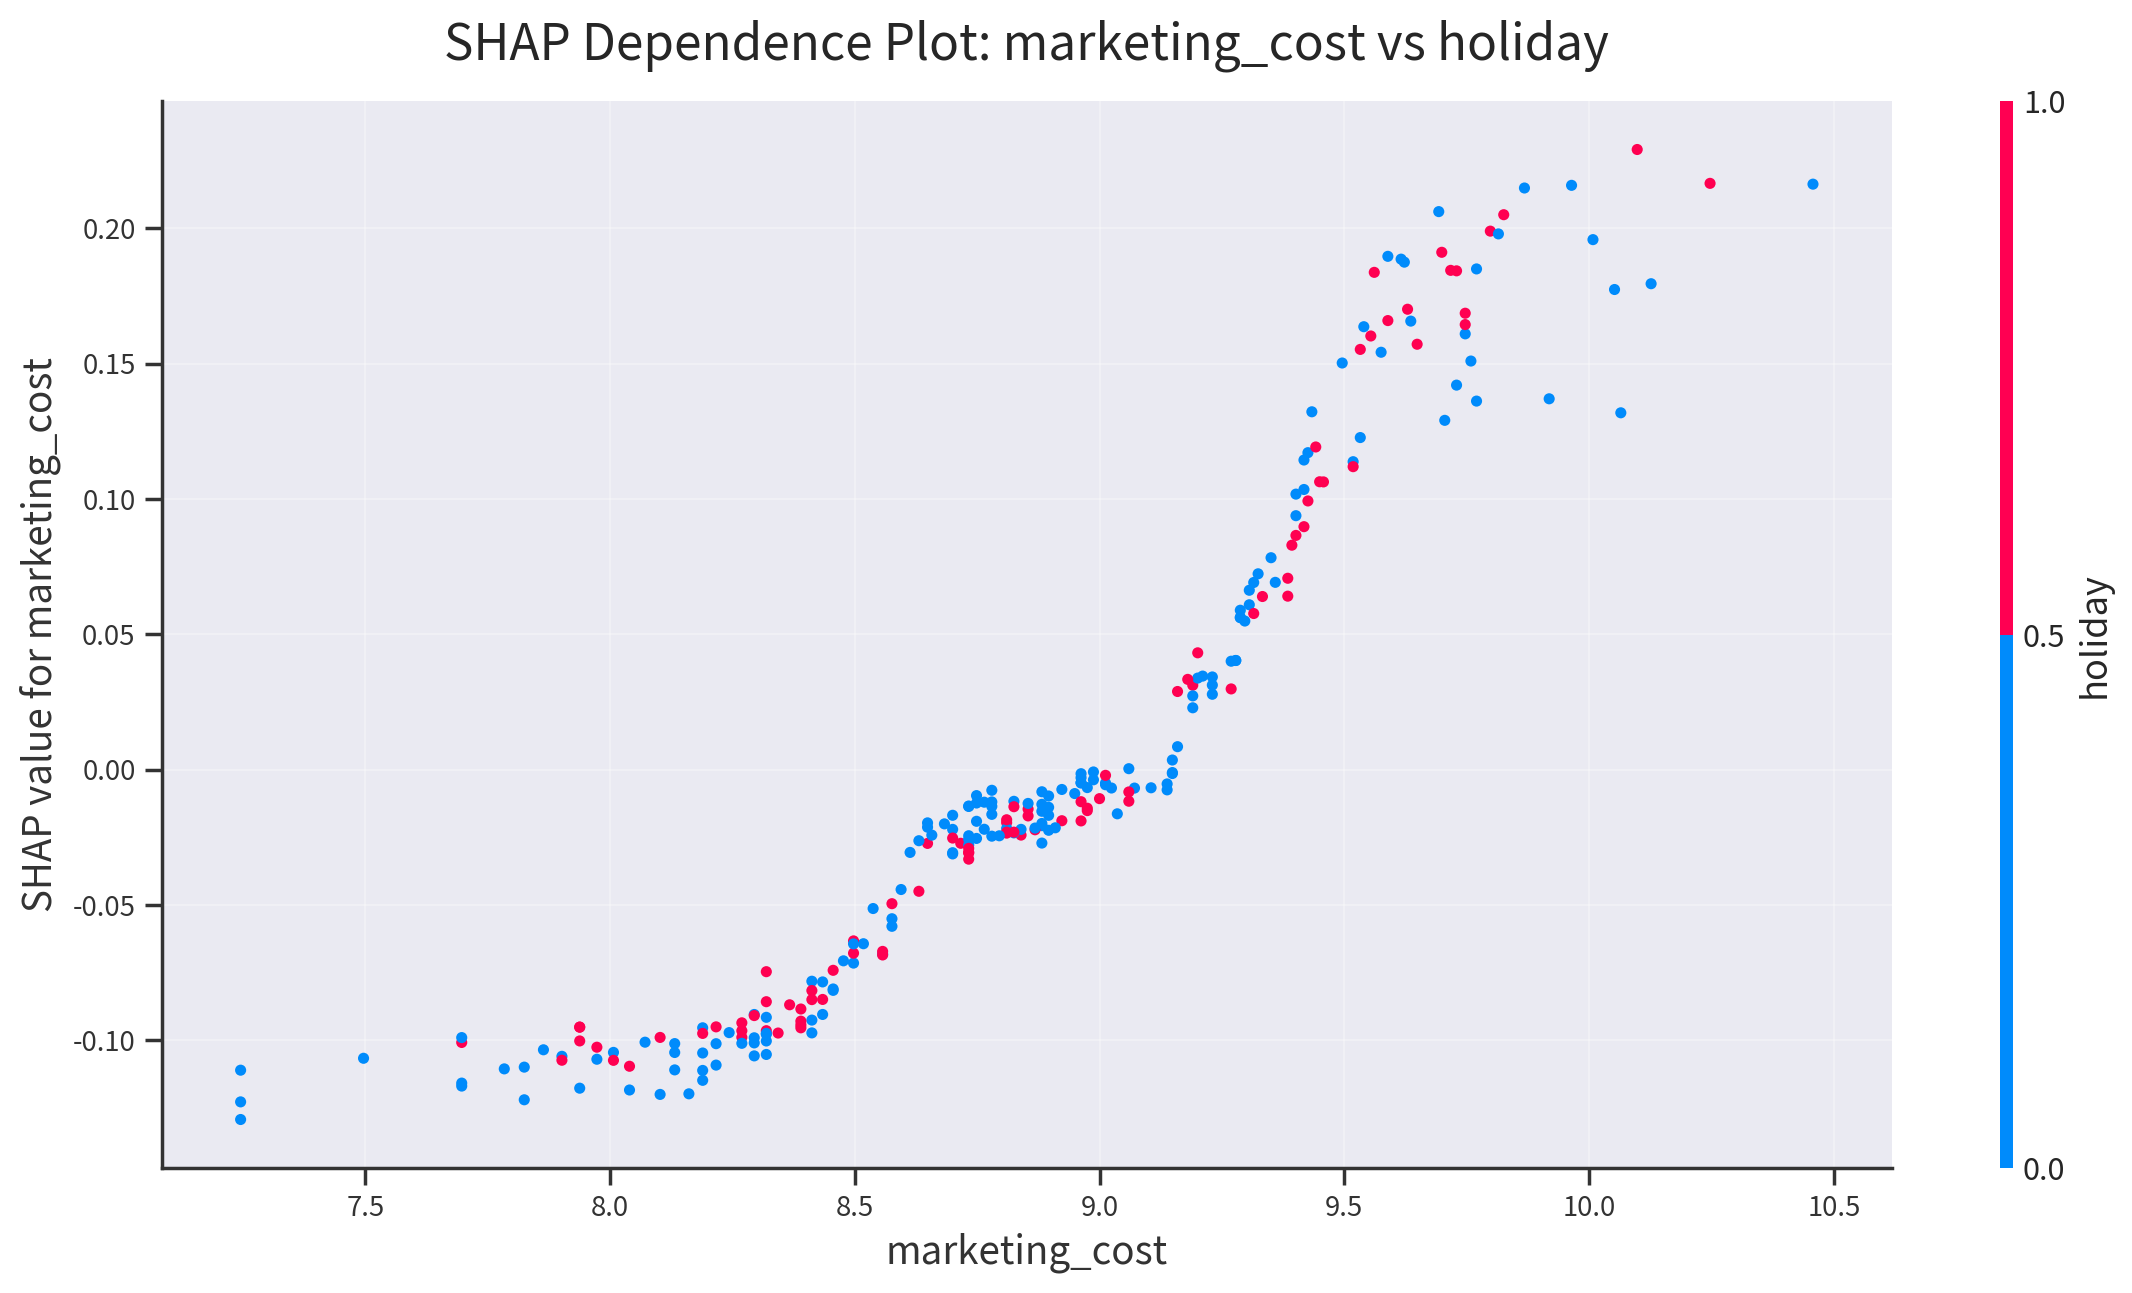

[('holiday', 'weekend'),
 ('marketing_cost', 'weekend'),
 ('marketing_cost', 'holiday')]

In [33]:
hs_shap_dependence_analysis(summary_df,shap_values,x_train)